<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista7-MateuszOlech/blob/main/Lista7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LISTA 7 - Klasteryzacja

## Importy

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

from scipy.io import arff
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

In [115]:
scaler = StandardScaler()
pca = PCA(n_components=2)

## 1 Analiza zbioru danych

Dokonaj eksploracyjnej analizy danych. Powinna obejmować co najmniej przegląd statystyk zbioru oraz wizualizacje dystrybucji danych. Nie pokazuj wszystkich możliwych wykresów cech parami, gdyż będzie ich zwyczajnie zbyt dużo; zidentyfikuj i przedstaw wyłącznie interesujące pary. Podejmij na tym etapie decyzje dotyczące wstępnego przetwarzania.

In [116]:
source = arff.loadarff('/content/Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [117]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


|Cecha|Typ|Opis|
|:---:|---|:---|
|Area|`float64`|Powierzchnia fasoli i lizcba pikseli w jej granicach|
|Perimeter|`float64`|Obwód fasoli|
|MajorAxisLength|`float64`|Maksymalna długość fasoli|
|MinorAxisLength|`float64`|Maksymalna szerokość fasoli|
|AspectRation|`float64`|Stosunek maksymalnej długości do maksymalnej szerokości|
|Eccentricity|`float64`|Miara spłaszczenia (jak bardzo przypomina elipsę)|
|ConvexArea|`float64`|Powierzchnia najmniejszego wielokąta wypukłego opisującego fasolę|
|EquivDiameter|`float64`|Średnica koła o powierzchni fasoli|
|Extent|`float64`|Miara wypełnienia (stosunek powierzchni do najmniejszego prostokąta opisanego na fasoli)|
|Solidity|`float64`|Miara wklęsłości|
|roundness|`float64`|Miara podobieństwa fasoli do idealnego koła|
|Compactness|`float64`|Proporcja średnicy koła do maksymalnej długości fasoli|
|ShapeFactor1|`float64`|-|
|ShapeFactor2|`float64`|-|
|ShapeFactor3|`float64`|-|
|ShapeFactor4|`float64`|-|
|Class|`object`|Jedna z 7 odmian fasoli|

In [118]:
numerical_df = df.select_dtypes(include=['number'])
summary = numerical_df.describe().T

summary_table = summary[['min', 'max', 'mean', 'std']].copy()

summary_table.columns = ['Min', 'Max', 'Średnia', 'Odchylenie standardowe']
summary_table.index.name = 'Cecha'
summary_table = summary_table.reset_index()
pd.set_option('display.float_format', lambda x: '%.6f' % x)

summary_table

,Cecha,Min,Max,Średnia,Odchylenie standardowe
0,Area,20420.000000,254616.000000,53048.284549,29324.095717
1,Perimeter,524.736000,1985.370000,855.283459,214.289696
2,MajorAxisLength,183.601165,738.860153,320.141867,85.694186
3,MinorAxisLength,122.512653,460.198497,202.270714,44.970091
4,AspectRation,1.024868,2.430306,1.583242,0.246678
5,Eccentricity,0.218951,0.911423,0.750895,0.092002
6,ConvexArea,20684.000000,263261.000000,53768.200206,29774.915817
7,EquivDiameter,161.243764,569.374358,253.064220,59.177120
8,Extent,0.555315,0.866195,0.749733,0.049086
9,Solidity,0.919246,0.994677,0.987143,0.004660


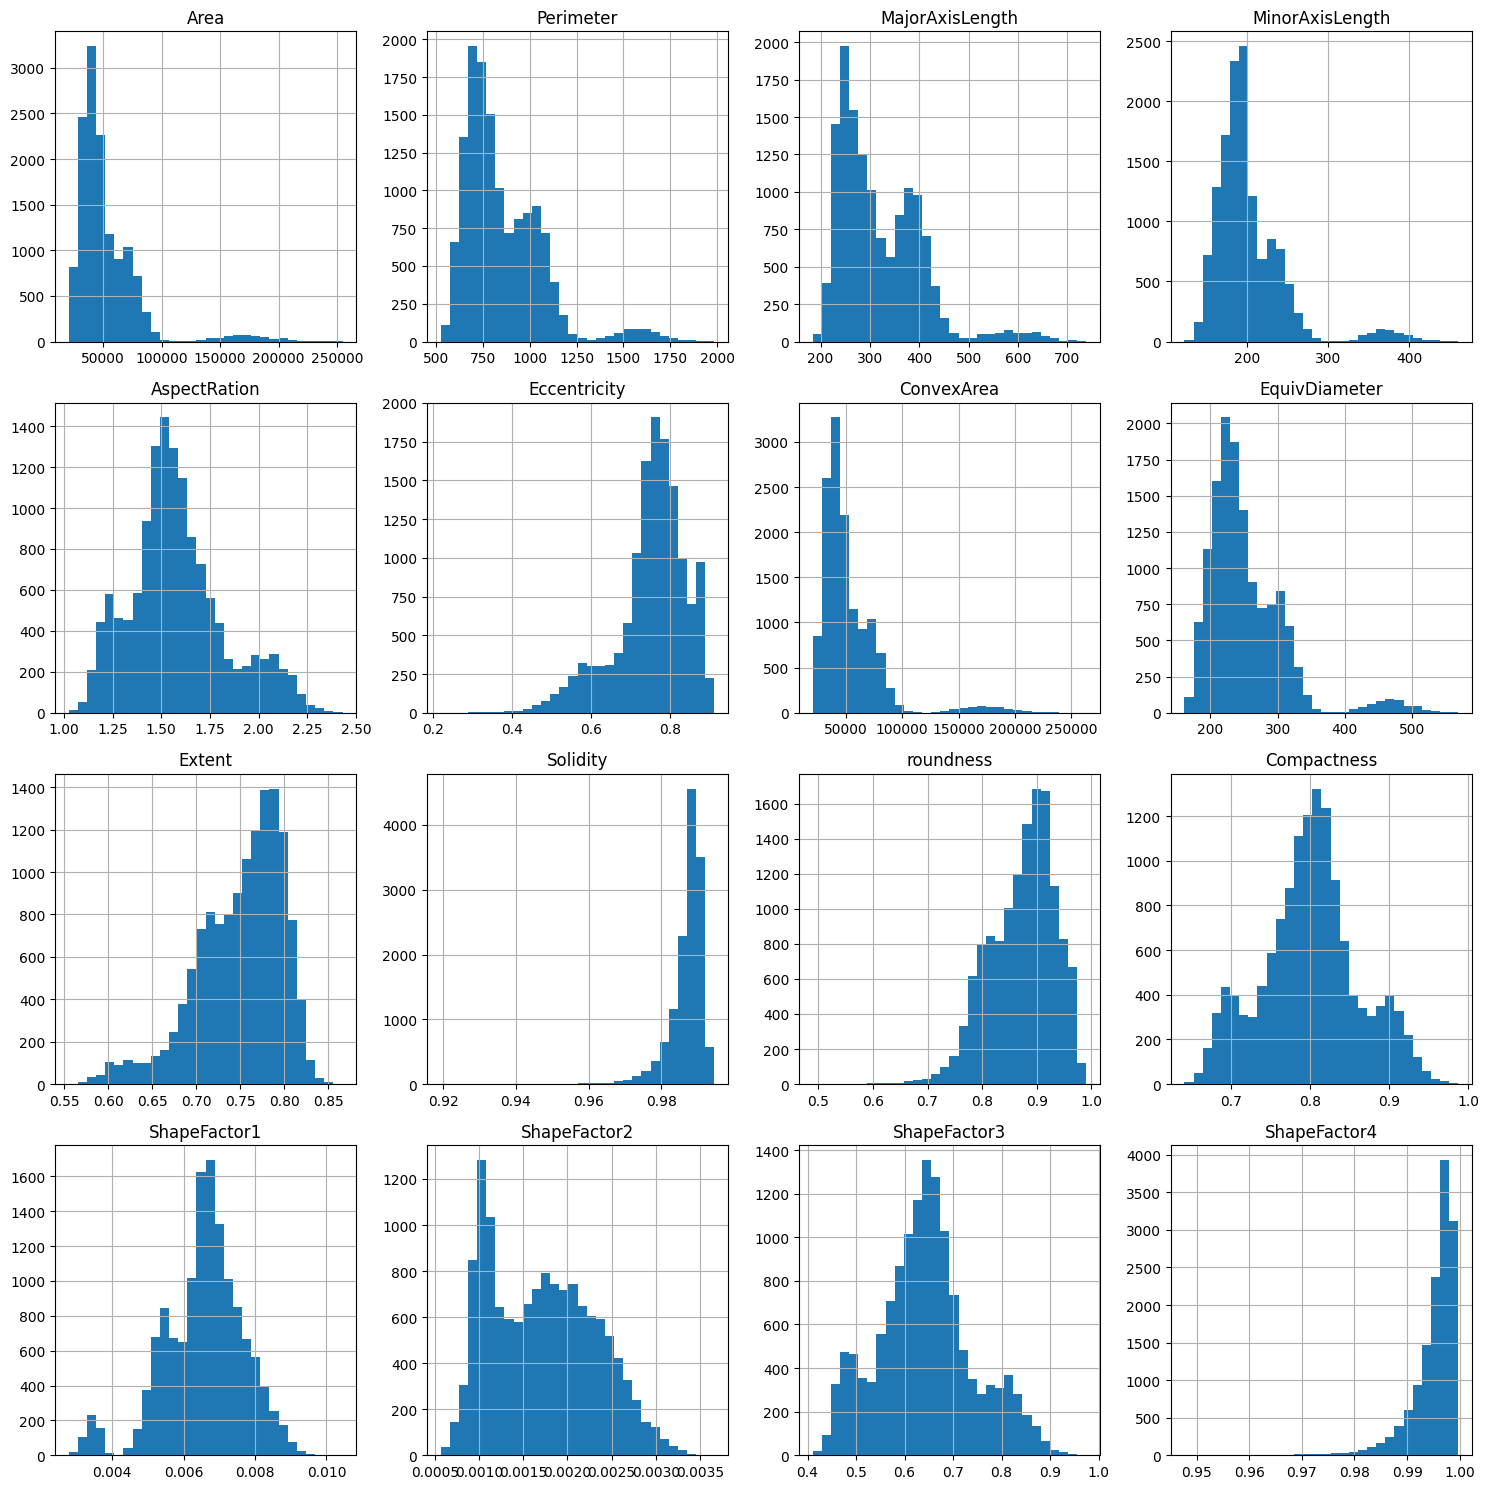

In [119]:
df.hist(bins=30, figsize=(15, 15), layout=(4, 4))
plt.tight_layout()
plt.show()

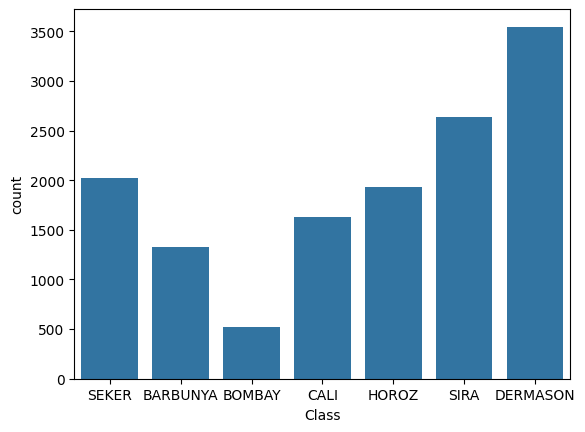

In [120]:
sns.countplot(data=df, x='Class')
plt.show()

In [121]:
Y = df['Class']
X = df.drop(columns=['Class']).copy()

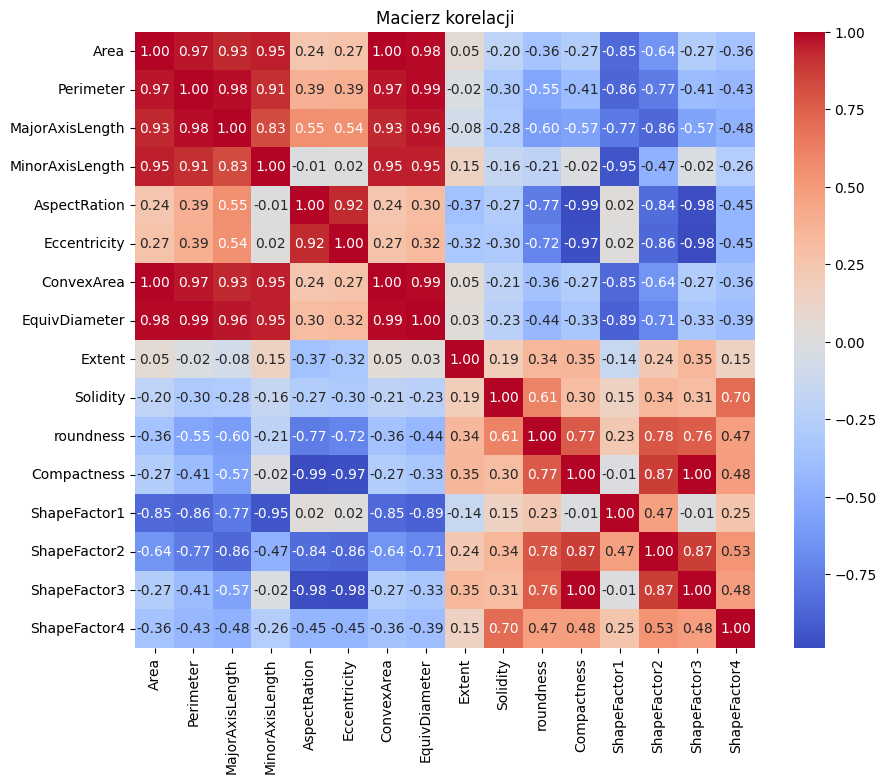

In [122]:
# macierz korelacji
corr_matrix = X.corr()

# wizualizacja macierzy korelacji
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

Cechy do odrzucenia:
- ConvexArea, EquivDiameter (zostaje Area) - mówią o wielkości fasoli
- Eccentricity (zostaje AspectRation) - opisują podobne zjawisko
- ShapeFactor3 (Compactness) - korelacja 1.0 - mówią o tym samym
- Perimeter (zostaje Area i dłu + szer) - zbyt duże korelacje, po co nam 4 miary opisujące wielkość
- AspectRation (Compactness) - korelacja na poziomie -0.99

In [123]:
# Oblicz macierz korelacji
corr_matrix = X.corr().abs()

# Wybierz górny trójkąt macierzy (aby nie usuwać par 2 razy)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Znajdź kolumny do usunięcia (korelacja > 0.98)
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]

print(f"Usuwam cechy: {to_drop}")
X_reduced = X.drop(columns=to_drop).copy()

Usuwam cechy: ['ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor3']


In [124]:
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

X_scaled_reduced = scaler.fit_transform(X_reduced)
X_pca_reduced = pca.fit_transform(X_scaled_reduced)

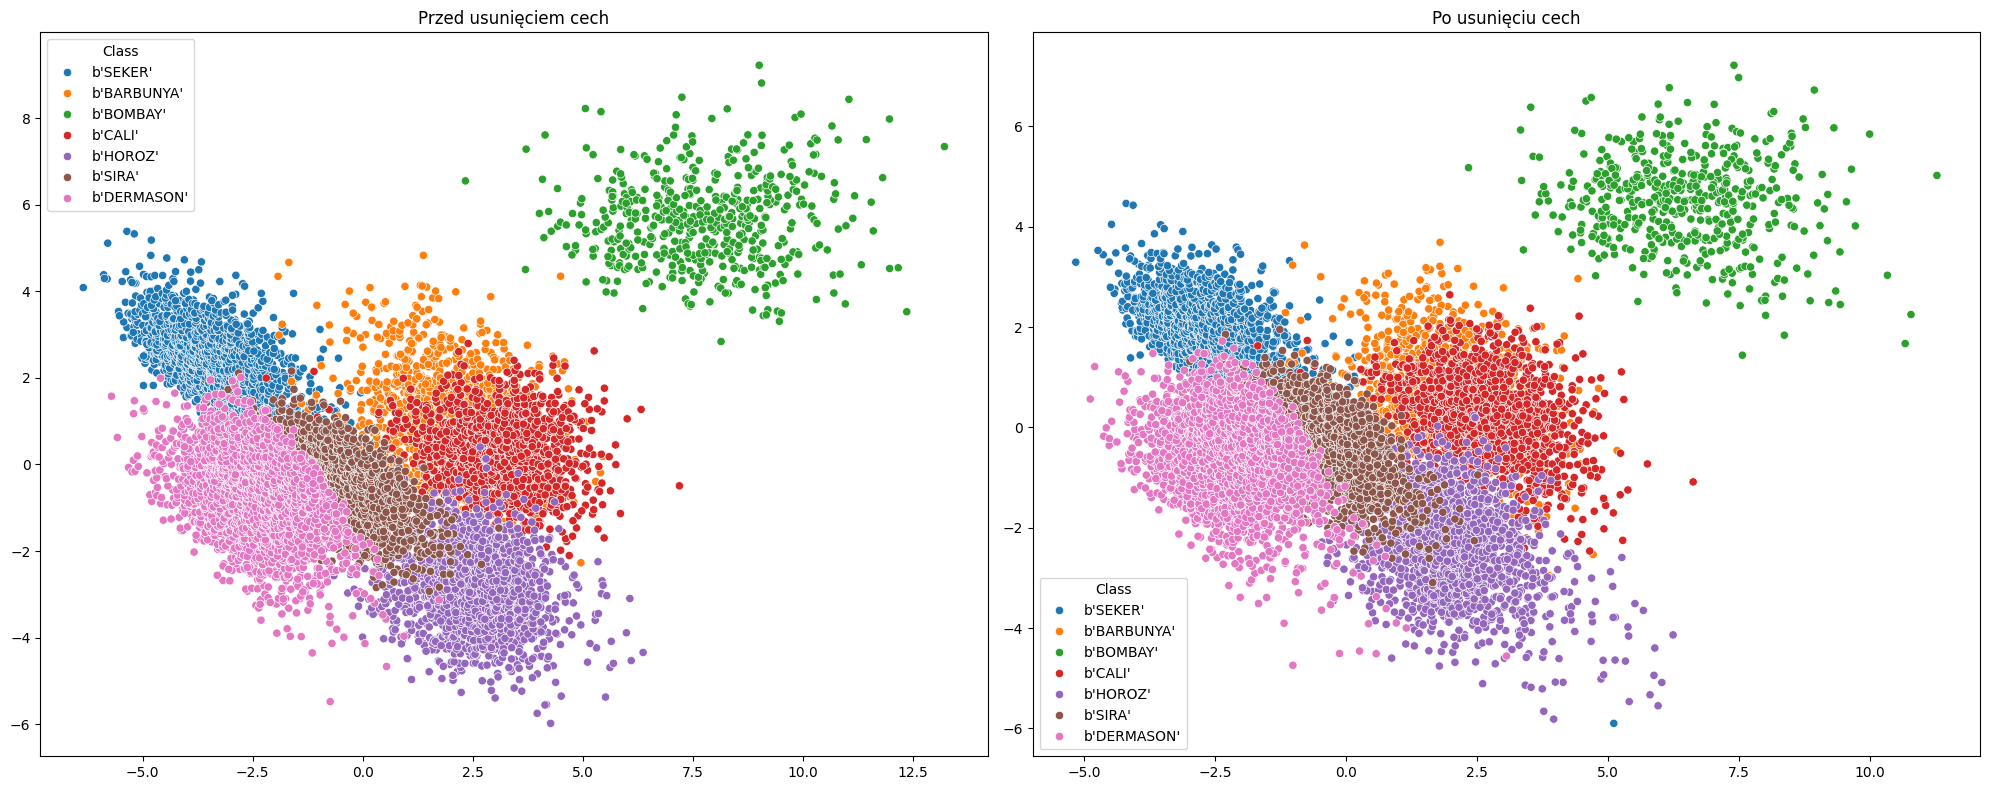

In [125]:
fig, axes = plt.subplots(1,2, figsize=(20, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=Y, ax=axes[0])
axes[0].set_title('Przed usunięciem cech')
sns.scatterplot(x=X_pca_reduced[:, 0], y=X_pca_reduced[:, 1], hue=Y, ax=axes[1])
axes[1].set_title('Po usunięciu cech')

plt.tight_layout()
plt.show()

Usunięcie najbardziej skorelowanych cech nie wpłynęło na polepszenie redukcji wymiarowości za pomocą PCA. Zatem najlepszym wariantem pozostaje PCA na oryginalnym zbiorze, nawet mimo silnie skorelowanych ze sobą cech.

## 2 Algorytm k-średnich

### 2.1 Przygotowanie
Uruchom algorytm k-średnich (sklearn.cluster.KMeans, 4) na przetworzonym zbiorze
danych. Na ten moment przyjmij dowolną liczbę k. Odczytaj wartość miary inercji grupowania.
Opracuj funkcję do wizualizacji wyniku klasteryzacji; możesz posłużyć się przykładami
z tutorialu, ale zadbaj o dopasowanie ich do zbioru danych użytego w tej części listy (patrz:
sekcja o analizie danych).

In [126]:
k_means = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_pca)

inertia = k_means.inertia_
print(f"Wartość miary inercji: {inertia}")

Wartość miary inercji: 39659.264458800615


In [127]:
# funkcja do wizualizacji algorytmu
def show_simple(dataset: np.ndarray, indices: np.ndarray, centers: np.ndarray, aspect='equal'):
    fig, ax = plt.subplots(1, 1, figsize=(10,8))
    ax.set_aspect(aspect)
    ax.scatter(dataset[:, 0], dataset[:, 1], c=indices, cmap='Set1', vmin=0, vmax=8)
    ax.scatter(centers[:, 0], centers[:, 1], marker='o', c='black', label='Centroidy')
    ax.legend()
    plt.tight_layout()
    plt.show()

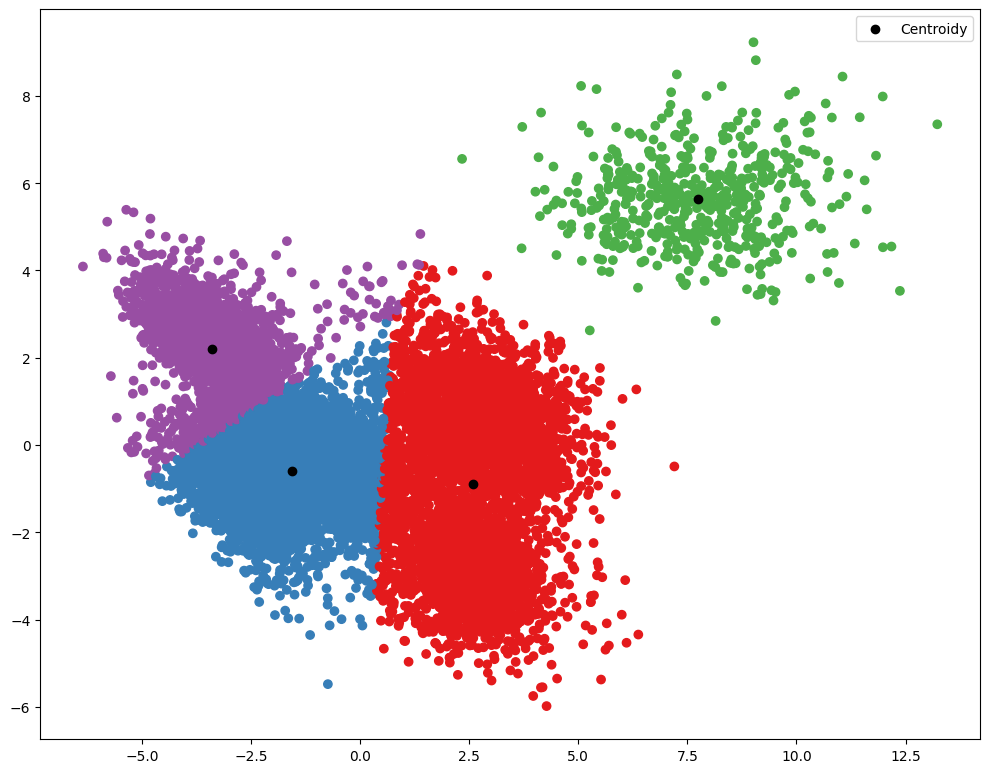

In [128]:
show_simple(X_pca, k_means.labels_, k_means.cluster_centers_)

### 2.2 Badanie wpływu parametru k
- Używając przygotowanej powyżej infrastruktury, wykonaj badanie wpływu liczby klastrów na działanie algorytmu.
- Przedstaw na wykresach wpływ k na inercję oraz na miary jakości grupowania: silhouette oraz purity.
- Wybierz najistotniejsze wartości k i zwizualizuj uzyskane dla nich wyniki.


Co to znaczy „optymalna” wartość k i w jaki sposób ją wybrać?

In [129]:
def purity_score(labels_true: np.ndarray, labels_pred: np.ndarray) -> float:
    # 1. Oblicz macierz contingency (podobna do macierzy pomyłek - doczytaj)
    # Jej wiersze odpowiadają klasom (Y), a kolumny klastrom (przewidzianym)
    cont_matrix = metrics.cluster.contingency_matrix(labels_true, labels_pred)

    # 2. Dla każdego klastra oblicz maksymalną liczbę należących do niego przykładów z jednej klasy
    max_per_cluster = np.max(cont_matrix, axis=0)

    # 3. Zsumuj te maksymalne wartości i podziel przez całkowitą liczbę przykładów
    return np.sum(max_per_cluster) / np.sum(cont_matrix)

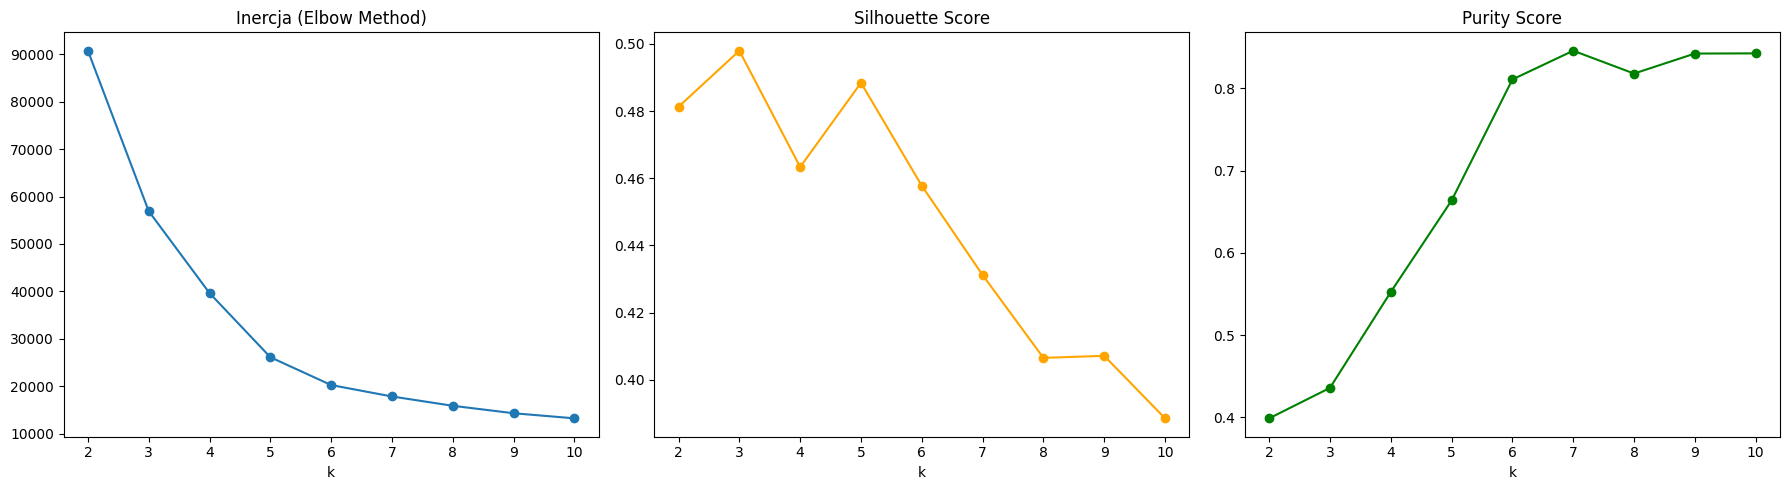

In [130]:
k_values = range(2, 11)
inertias = []
purities = []
silhouettes = []

for k in k_values:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    inertias.append(k_means.inertia_)
    purities.append(purity_score(Y, k_means.labels_))
    silhouettes.append(metrics.silhouette_score(X_pca, k_means.labels_))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(k_values, inertias, 'o-')
axes[0].set_title('Inercja (Elbow Method)')
axes[0].set_xlabel('k')

axes[1].plot(k_values, silhouettes, 'o-', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')

axes[2].plot(k_values, purities, 'o-', color='green')
axes[2].set_title('Purity Score')
axes[2].set_xlabel('k')

plt.tight_layout()
plt.show()

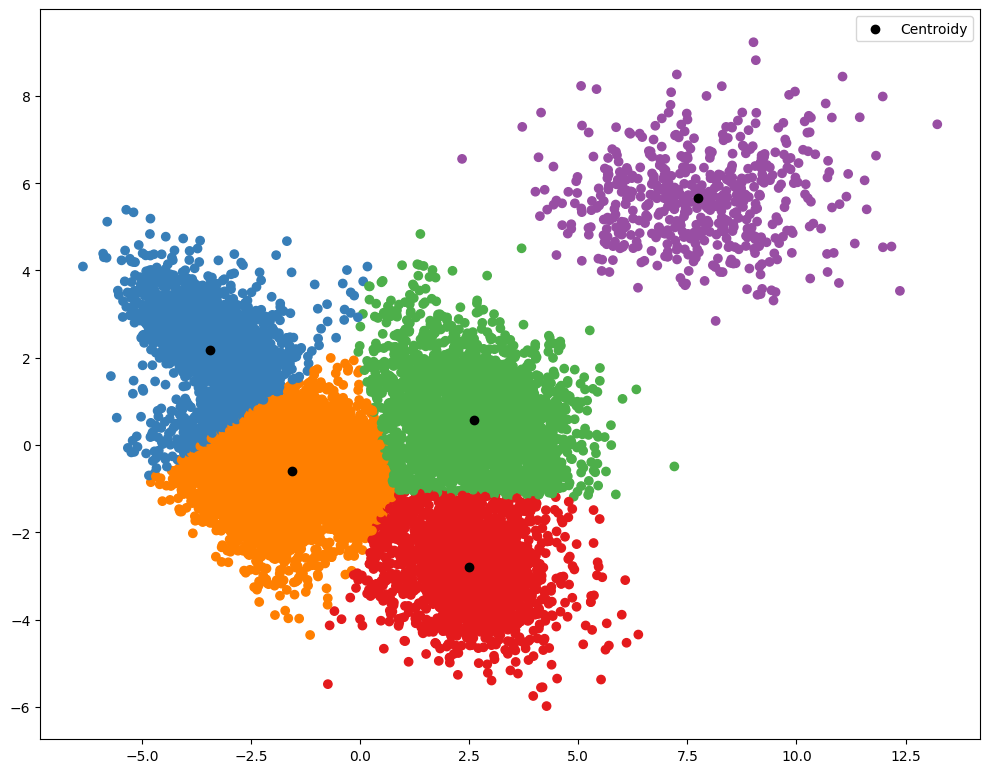

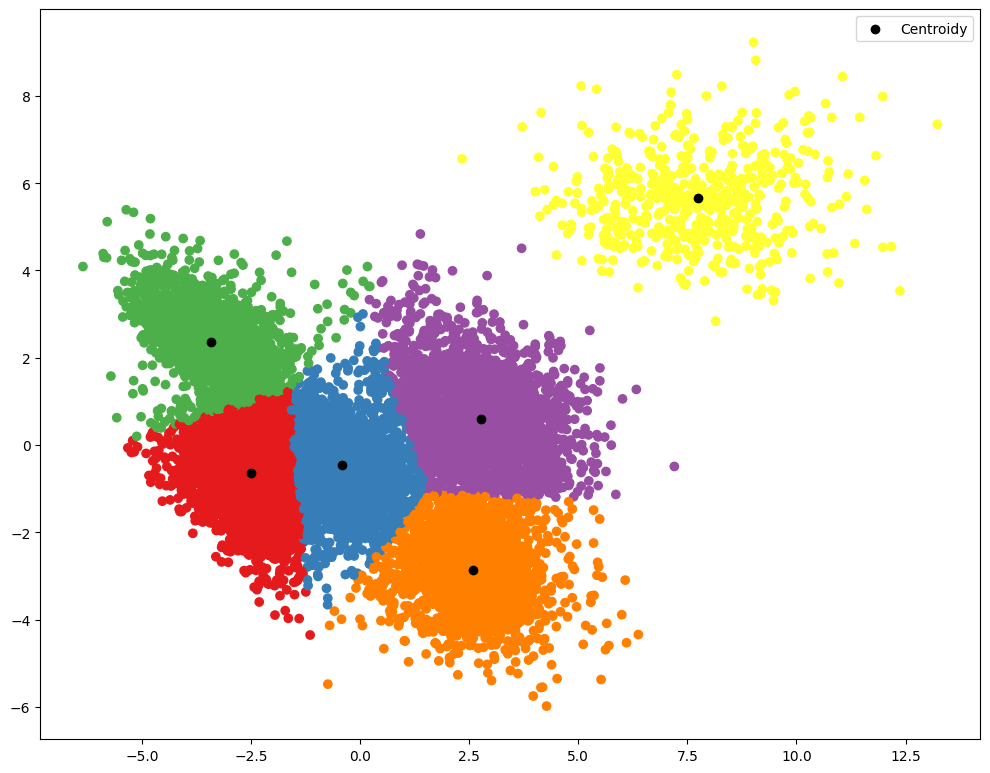

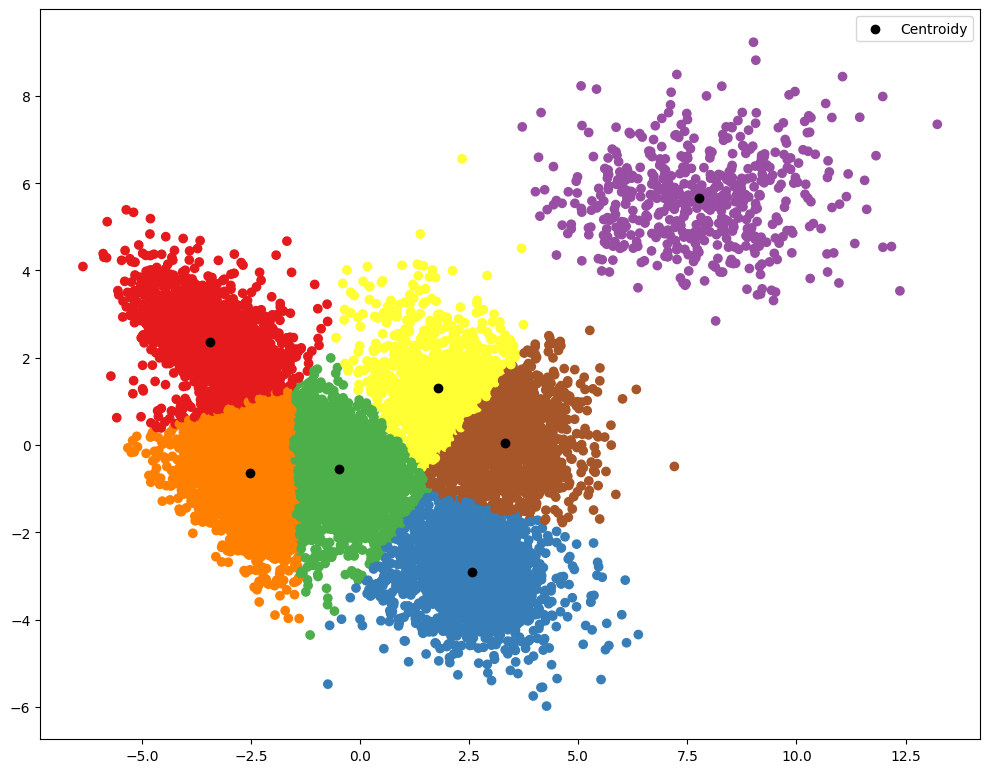

In [131]:
# wizualizacja dla k = 5, 6 i 7
for k in [5,6,7]:
    k_means = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    show_simple(X_pca, k_means.labels_, k_means.cluster_centers_)

- ***Inercja*** - miara zwartości klastrów, im mniejsza wartość tym punkty są ciaśniej skupione wokół środka. Maleje wraz ze wzrostem *k*; szukamy takiego *k*, dla którego następuje załamanie spadku (tzw. łokcia), czyli miejsca od którego wartości maleją coraz mniej drastycznie.

- ***Silhouette Score*** - ocena zarówno zwartości klastra jak i jego odesparowania od pozostałych klastrów.

- ***Purity*** - sprawdza, w jakim stopniu dany klaster jest zdominowany przez jedną klasę.

Optymalna wartość *k* to po prostu najlepszy możliwy kompromis między matematyczną spójnością klastrów a rzeczywistym podziałem danych. Przy wyborze *k* nie możemy opierać się tylko na jednej z tych metryk, tylko znaleźć najlepszą optymalną wartość wspólną.

## Zadanie 3

### 3.1 Badanie
Podobnie jak w przypadku k-średnich, najistotniejszym parametrem metody jest pożądana liczba klastrów1. Przeprowadź badanie wpływu tego parametru na wyniki klasteryzacji algorytmem aglomeracyjnym.

Nie zmieniaj pozostałych parametrów, w szczególności pozostań przy metryce euklidesowej i kryterium łączenia ward (w przypadku uzyskania wyraźnie niesatysfakcjonujących wyników możesz przetestować inne strategie). Wyniki, jak poprzednio, przedstaw na wykresach i wizualizacjach. Zadbaj o to, by możliwe było wygodne porównanie działania obu
badanych w liście algorytmów.

In [133]:
purities_agg = []
silhouettes_agg = []

for k in k_values:
    agg_clustering = AgglomerativeClustering(n_clusters=k, metric='euclidean' ,linkage='ward')
    labels_agg = agg_clustering.fit_predict(X_pca)
    purities_agg.append(purity_score(Y, labels_agg))
    silhouettes_agg.append(metrics.silhouette_score(X_pca, labels_agg))


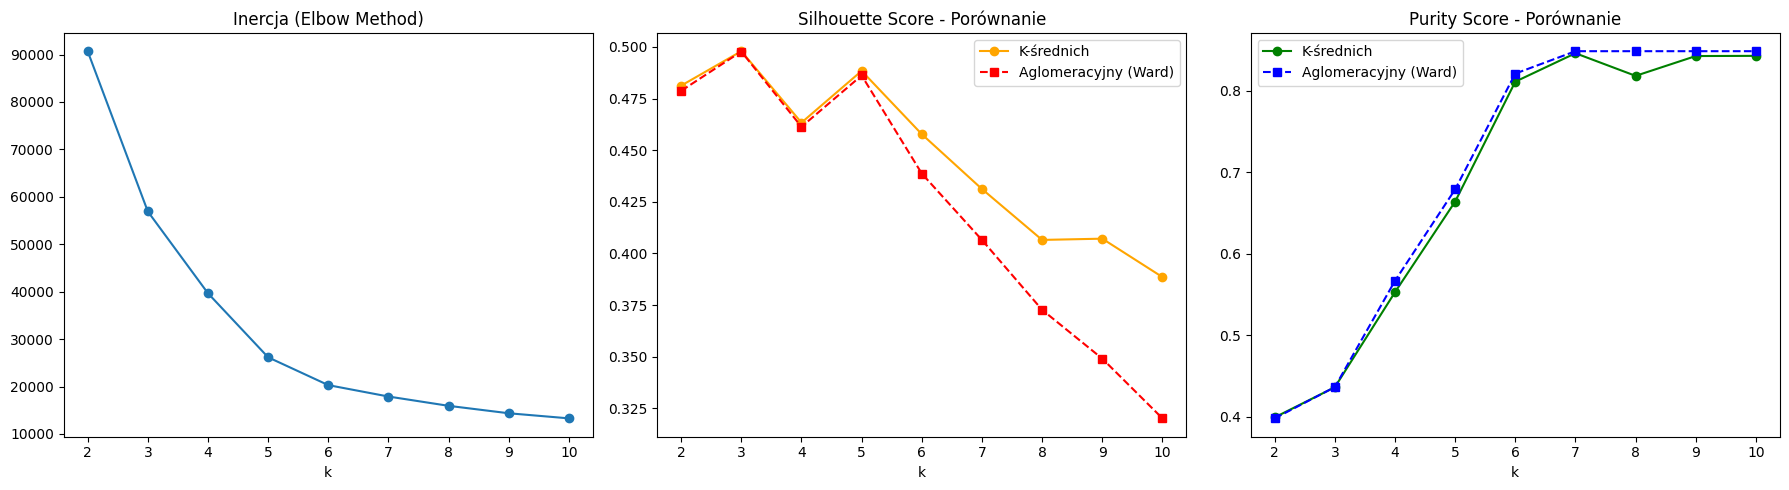

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_values, inertias, 'o-')
axes[0].set_title('Inercja (Elbow Method)')
axes[0].set_xlabel('k')

axes[1].plot(k_values, silhouettes, 'o-', color='orange', label='K-średnich')
axes[1].plot(k_values, silhouettes_agg, 's--', color='red', label='Aglomeracyjny (Ward)')
axes[1].set_title('Silhouette Score - Porównanie')
axes[1].set_xlabel('k')
axes[1].legend()

axes[2].plot(k_values, purities, 'o-', color='green', label='K-średnich')
axes[2].plot(k_values, purities_agg, 's--', color='blue', label='Aglomeracyjny (Ward)')
axes[2].set_title('Purity Score - Porównanie')
axes[2].set_xlabel('k')
axes[2].legend()

plt.tight_layout()
plt.show()

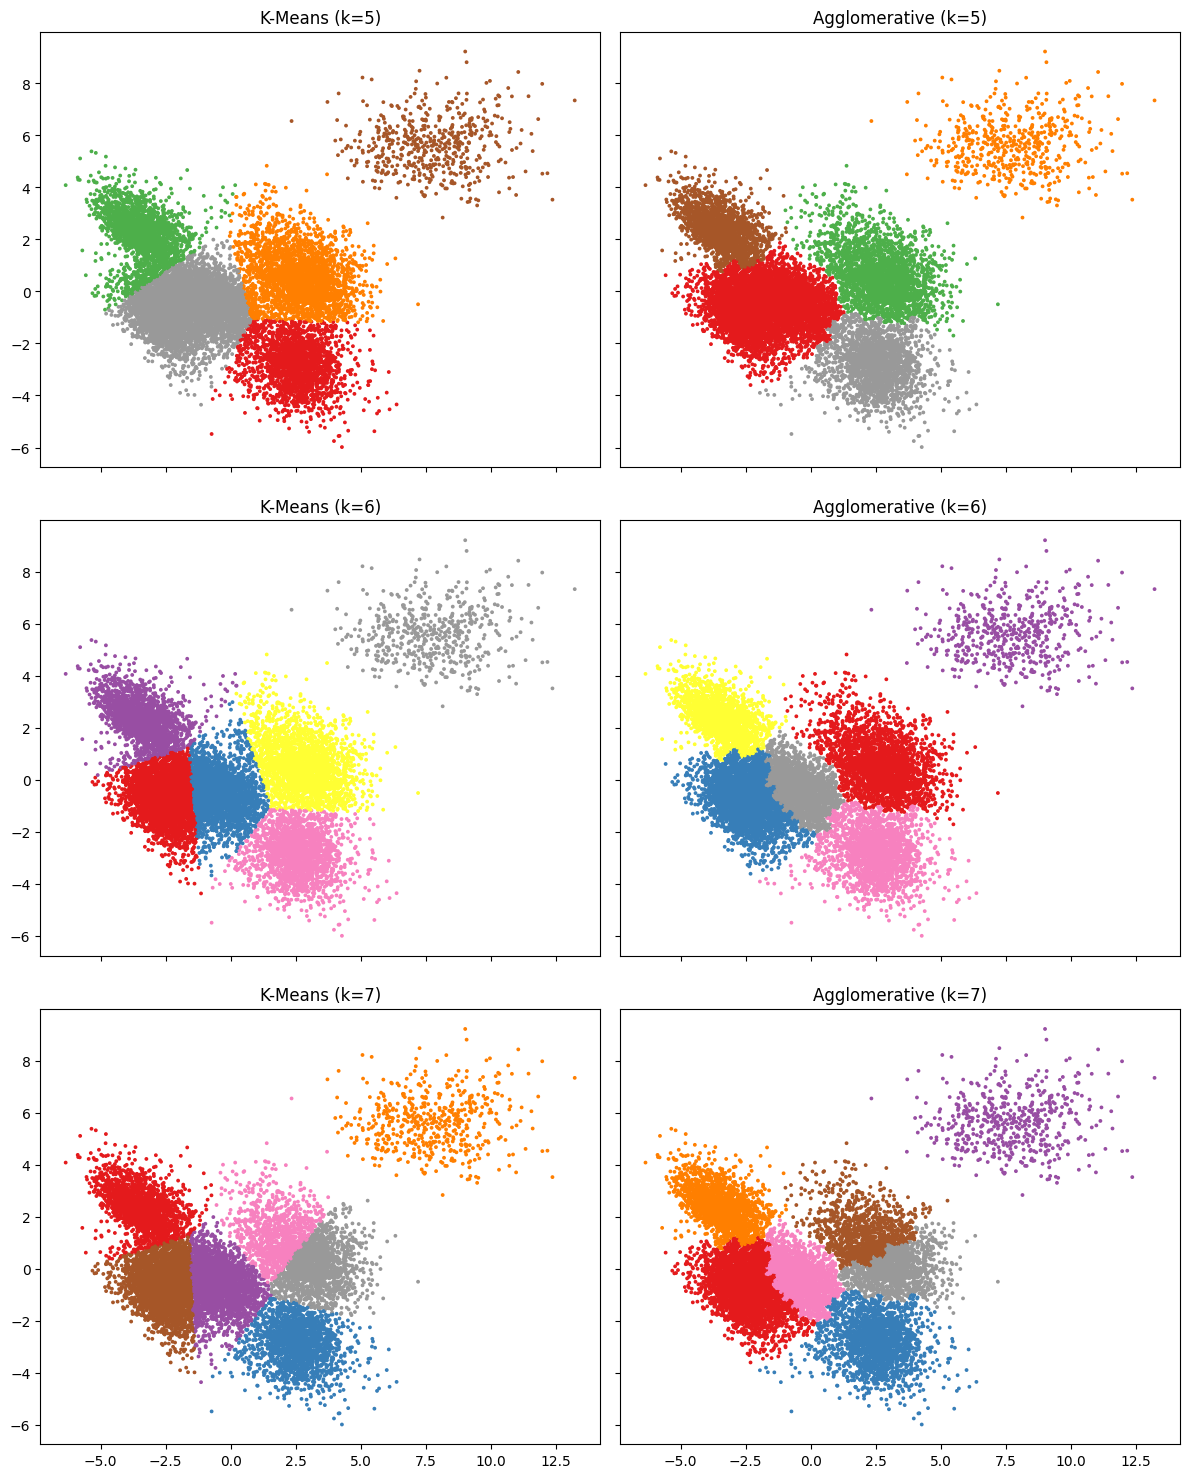

In [136]:
k_to_viz = [5, 6, 7]

fig, axes = plt.subplots(3, 2, figsize=(12, 15), sharex=True, sharey=True)

for i, k in enumerate(k_to_viz):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pca)
    axes[i, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='Set1', s=3)
    axes[i, 0].set_title(f'K-Means (k={k})')
    axes[i, 0].set_aspect('equal')

    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward').fit(X_pca)
    axes[i, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=agg.labels_, cmap='Set1', s=3)
    axes[i, 1].set_title(f'Agglomerative (k={k})')
    axes[i, 1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 3.2 Pomiar czasu
Zmierz i porównaj czas działania algorytmów k-średnich i aglomeracyjnego; uwzględnij
wyniki tego porównania we wnioskach. Dowiedz się, w jaki sposób przeprowadzić metodologicznie poprawny pomiar czasu działania algorytmu w języku Python.


In [138]:
# porównanie czasów
k_opt = 7
repeats = 5

time_kmeans = []
for _ in range(repeats):
  kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
  start_time = time.time()
  kmeans.fit(X_pca)
  end_time = time.time()
  time_kmeans.append(end_time - start_time)

time_agg = []
for _ in range(repeats):
  agg = AgglomerativeClustering(n_clusters=k_opt, metric='euclidean', linkage='ward')
  start_time = time.time()
  agg.fit(X_pca)
  end_time = time.time()
  time_agg.append(end_time - start_time)

print(f"średni czas działania algorytmu k-średnich:      {np.mean(time_kmeans):.3f}s (± {np.std(time_kmeans):.4f} s)")
print(f"średni czas działania algorytmu aglomeracyjnego: {np.mean(time_agg):.3f}s  (± {np.std(time_agg):.4f} s) ")

średni czas działania algorytmu k-średnich:      0.521s (± 0.1398 s)
średni czas działania algorytmu aglomeracyjnego: 15.185s  (± 1.1850 s) 
